# Skin Cancer Detection using Transfer Learning

This project creates a classifier for belign and malignant moles. I will use transfer learning.

The dataset can be found here: https://www.kaggle.com/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/data

In [1]:
#Import the libraries
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os
import torchsummary
from torchvision import models
from pathlib import Path
import torch.optim.lr_scheduler as lr_scheduler
import copy
np.random.seed(42)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
image_path = []
labels = []
for i in os.listdir("Data"):
    print(i)
    for label in os.listdir(f"Data/{i}"):
        for image in os.listdir(f"Data/{i}/{label}"):
            image_path.append(f"Data/{i}/{label}/{image}")
            labels.append(label)
data_df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "label"])
data_df.head()

test
train


,image_path,label
0,Data/test/Benign/6299.jpg,Benign
1,Data/test/Benign/6300.jpg,Benign
2,Data/test/Benign/6301.jpg,Benign
3,Data/test/Benign/6302.jpg,Benign
4,Data/test/Benign/6303.jpg,Benign


I am going to split it myself into the test train validation.

In [4]:
#split into train test and validation
train = data_df.sample(frac=0.7, random_state=42)
test = data_df.drop(train.index)
validation = test.sample(frac=0.5, random_state=42)
test = test.drop(validation.index)

In [5]:
print(train.shape)
print(test.shape)
print(validation.shape)

(9715, 2)
(2082, 2)
(2082, 2)


In [6]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["label"])
num_classes = len(label_encoder.classes_)
num_classes # it is two (benign and malignant)
    

2

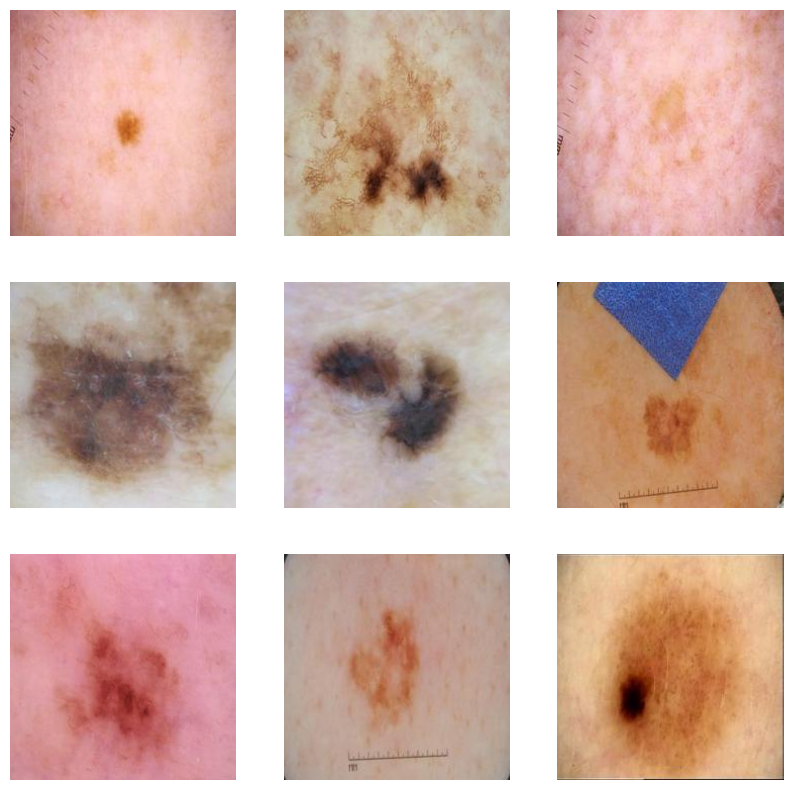

In [7]:
n_rows = 3
n_cols = 3 
f, axarr = plt.subplots(n_rows, n_cols, figsize=(10, 10))
for i in range(n_rows):
    for j in range(n_cols):
        image =Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
        axarr[i, j].imshow(image)
        axarr[i, j].axis('off')
plt.show()

In [36]:
class_counts = data_df["label"].value_counts().sort_index()
print("class distribution (%) in the training dataset:")
class_percentages = (class_counts / class_counts.sum() * 100).round(2)
class_percentages

class distribution (%) in the training dataset:


label
Benign       52.52
Malignant    47.48
Name: count, dtype: float64

So the most basic classifier of just picking the modal class would get an accuracy of 0.525.

i think we can do better.

# The Model

In [ ]:
#This is the recommended transformation for googlenet and convnext models.
test_transform = transforms.Compose([
    transforms.Resize((256 , 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225] ,
    ),
])
    



train_transform = transforms.Compose([
    transforms.Resize((256 , 256)),
    transforms.CenterCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(40),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.3),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [45]:
class CustomImageDataset (Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe["label"])).to(device)
    
    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image).to(device)
        return image, label

In [46]:
aug_train_dataset = CustomImageDataset(train, transform=train_transform)
aug_val_dataset = CustomImageDataset(validation, transform=test_transform)
aug_test_dataset = CustomImageDataset(test, transform=test_transform)

In [47]:
BATCH_SIZE = 32
aug_train_loader = DataLoader(
    aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
aug_val_loader = DataLoader(
    aug_val_dataset, batch_size=BATCH_SIZE, shuffle=False
)
aug_test_loader = DataLoader(
    aug_test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

In [ ]:
LR = 1e-3
EPOCHS = 30
patience = 3  # Number of epochs to wait for improvement before early stopping
# Create a new pretrained GoogLeNet
googlenet_aug_model = models.googlenet(weights="DEFAULT")

# Freeze all pretrained weights
for param in googlenet_aug_model.parameters():
    param.requires_grad = False

# Fine-tune only the final inception blocks
googlenet_aug_model.inception5a.requires_grad_(True)
googlenet_aug_model.inception5b.requires_grad_(True)

# Replace the classifier
googlenet_aug_model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(googlenet_aug_model.fc.in_features, num_classes),
)

googlenet_aug_model.to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(
    filter(lambda p: p.requires_grad, googlenet_aug_model.parameters()),
    lr=3e-4,
    weight_decay=1e-4,
)

scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2,
)

aug_train_losses = []
aug_val_losses = []
aug_train_accuracies = []
aug_val_accuracies = []

best_val_loss = float("inf")
best_model_weights = None
patience_counter = 0

for epoch in range(EPOCHS):
    googlenet_aug_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels_batch in aug_train_loader:
        inputs = inputs.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = googlenet_aug_model(inputs)

        if hasattr(outputs, "logits"):
            outputs = outputs.logits

        loss = loss_function(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels_batch.size(0)
        train_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
        train_total += labels_batch.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_accuracy = train_correct / train_total

    googlenet_aug_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels_batch in aug_val_loader:
            inputs = inputs.to(device)
            labels_batch = labels_batch.to(device)

            outputs = googlenet_aug_model(inputs)

            if hasattr(outputs, "logits"):
                outputs = outputs.logits

            loss = loss_function(outputs, labels_batch)

            val_loss += loss.item() * labels_batch.size(0)
            val_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_accuracy = val_correct / val_total

    aug_train_losses.append(epoch_train_loss)
    aug_val_losses.append(epoch_val_loss)
    aug_train_accuracies.append(epoch_train_accuracy)
    aug_val_accuracies.append(epoch_val_accuracy)

    scheduler.step(epoch_val_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f}, "
        f"Train Accuracy: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}, "
        f"Val Accuracy: {epoch_val_accuracy:.4f}"
        f" | Learning Rate: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(
            googlenet_aug_model.state_dict()
        )
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_model_weights is not None:
    googlenet_aug_model.load_state_dict(best_model_weights)

Epoch [1/30] | Train Loss: 0.3487, Train Accuracy: 0.8426 | Val Loss: 0.3186, Val Accuracy: 0.8756 | Learning Rate: 0.000300
Epoch [2/30] | Train Loss: 0.3034, Train Accuracy: 0.8710 | Val Loss: 0.2868, Val Accuracy: 0.8684 | Learning Rate: 0.000300
Epoch [3/30] | Train Loss: 0.2982, Train Accuracy: 0.8714 | Val Loss: 0.2757, Val Accuracy: 0.8919 | Learning Rate: 0.000300
Epoch [4/30] | Train Loss: 0.2775, Train Accuracy: 0.8829 | Val Loss: 0.2654, Val Accuracy: 0.9011 | Learning Rate: 0.000300
Epoch [5/30] | Train Loss: 0.2668, Train Accuracy: 0.8876 | Val Loss: 0.2765, Val Accuracy: 0.8871 | Learning Rate: 0.000300
Epoch [6/30] | Train Loss: 0.2649, Train Accuracy: 0.8861 | Val Loss: 0.2754, Val Accuracy: 0.9011 | Learning Rate: 0.000300
Epoch [7/30] | Train Loss: 0.2560, Train Accuracy: 0.8929 | Val Loss: 0.2488, Val Accuracy: 0.9044 | Learning Rate: 0.000300
Epoch [8/30] | Train Loss: 0.2498, Train Accuracy: 0.8979 | Val Loss: 0.2540, Val Accuracy: 0.8953 | Learning Rate: 0.000300


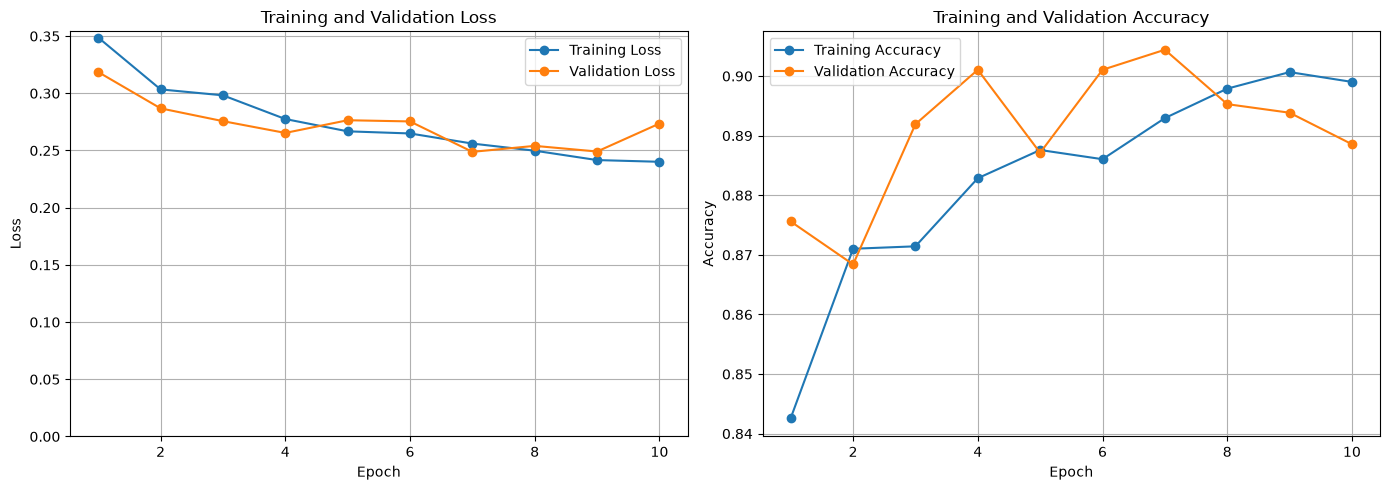

In [ ]:
epochs = range(1, len(aug_train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, aug_train_losses, marker="o", label="Training Loss")
axes[0].plot(epochs, aug_val_losses, marker="o", label="Validation Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_ylim(bottom=0)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, aug_train_accuracies, marker="o", label="Training Accuracy")
axes[1].plot(epochs, aug_val_accuracies, marker="o", label="Validation Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
#axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

We can see that the model seems to be underfitting so I will use a larger backbone.

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to C:\Users\nicho/.cache\torch\hub\checkpoints\convnext_base-6075fbad.pth


100%|██████████| 338M/338M [01:42<00:00, 3.45MB/s] 


ConvNeXt Epoch [1/30] | Train Loss: 0.3843, Train Accuracy: 0.8290 | Val Loss: 0.3207, Val Accuracy: 0.8569 | Learning Rate: 0.000300
ConvNeXt Epoch [2/30] | Train Loss: 0.3265, Train Accuracy: 0.8611 | Val Loss: 0.2881, Val Accuracy: 0.8876 | Learning Rate: 0.000300
ConvNeXt Epoch [3/30] | Train Loss: 0.3043, Train Accuracy: 0.8709 | Val Loss: 0.2752, Val Accuracy: 0.8794 | Learning Rate: 0.000300
ConvNeXt Epoch [4/30] | Train Loss: 0.3024, Train Accuracy: 0.8730 | Val Loss: 0.2589, Val Accuracy: 0.8929 | Learning Rate: 0.000300
ConvNeXt Epoch [5/30] | Train Loss: 0.2918, Train Accuracy: 0.8777 | Val Loss: 0.2471, Val Accuracy: 0.8886 | Learning Rate: 0.000300
ConvNeXt Epoch [6/30] | Train Loss: 0.2852, Train Accuracy: 0.8803 | Val Loss: 0.2404, Val Accuracy: 0.9015 | Learning Rate: 0.000300
ConvNeXt Epoch [7/30] | Train Loss: 0.2794, Train Accuracy: 0.8832 | Val Loss: 0.2370, Val Accuracy: 0.9001 | Learning Rate: 0.000300
ConvNeXt Epoch [8/30] | Train Loss: 0.2764, Train Accuracy: 0.

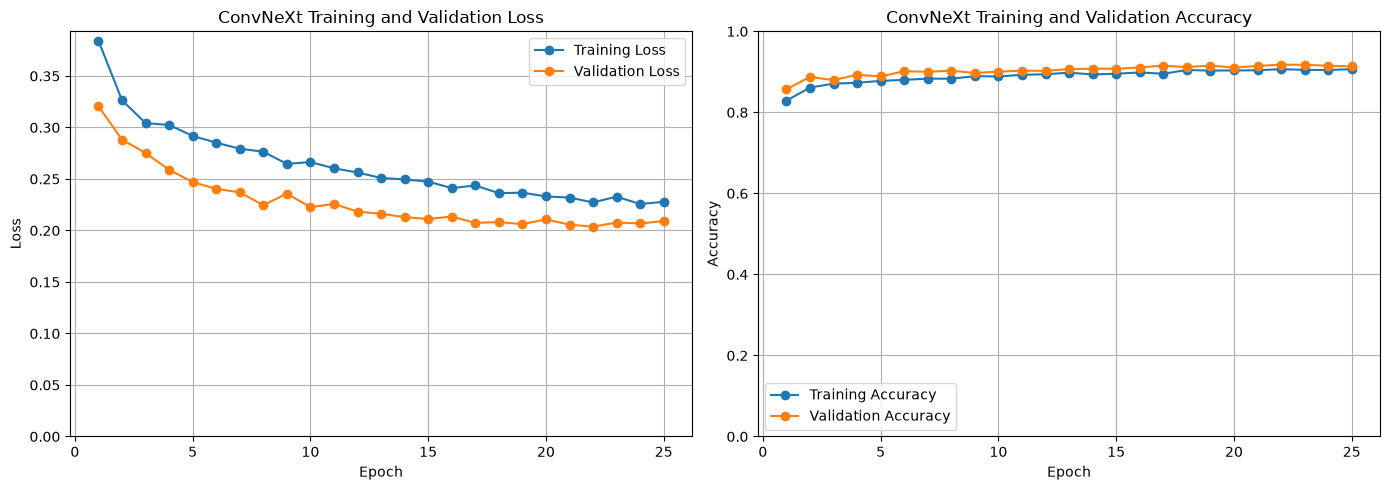

In [52]:
convnext_model = models.convnext_base(weights="DEFAULT")

for param in convnext_model.parameters():
    param.requires_grad = False

# Fine-tune the final ConvNeXt stage.
convnext_model.features[-1].requires_grad_(True)

convnext_model.classifier[2] = nn.Linear(
    convnext_model.classifier[2].in_features,
    num_classes,
 )
convnext_model.to(device)

convnext_loss_function = nn.CrossEntropyLoss()
convnext_optimizer = Adam(
    filter(lambda p: p.requires_grad, convnext_model.parameters()),
    lr=3e-4,
    weight_decay=1e-4,
 )
convnext_scheduler = lr_scheduler.ReduceLROnPlateau(
    convnext_optimizer,
    mode="min",
    factor=0.3,
    patience=2,
 )

convnext_train_losses = []
convnext_val_losses = []
convnext_train_accuracies = []
convnext_val_accuracies = []

convnext_best_val_loss = float("inf")
convnext_best_model_weights = None
convnext_patience_counter = 0

for epoch in range(EPOCHS):
    convnext_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels_batch in aug_train_loader:
        inputs = inputs.to(device)
        labels_batch = labels_batch.to(device)

        convnext_optimizer.zero_grad()
        outputs = convnext_model(inputs)
        loss = convnext_loss_function(outputs, labels_batch)
        loss.backward()
        convnext_optimizer.step()

        train_loss += loss.item() * labels_batch.size(0)
        train_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
        train_total += labels_batch.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_accuracy = train_correct / train_total

    convnext_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels_batch in aug_val_loader:
            inputs = inputs.to(device)
            labels_batch = labels_batch.to(device)

            outputs = convnext_model(inputs)
            loss = convnext_loss_function(outputs, labels_batch)

            val_loss += loss.item() * labels_batch.size(0)
            val_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_accuracy = val_correct / val_total

    convnext_train_losses.append(epoch_train_loss)
    convnext_val_losses.append(epoch_val_loss)
    convnext_train_accuracies.append(epoch_train_accuracy)
    convnext_val_accuracies.append(epoch_val_accuracy)

    convnext_scheduler.step(epoch_val_loss)

    print(
        f"ConvNeXt Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f}, "
        f"Train Accuracy: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}, "
        f"Val Accuracy: {epoch_val_accuracy:.4f} | "
        f"Learning Rate: {convnext_optimizer.param_groups[0]['lr']:.6f}"
    )

    if epoch_val_loss < convnext_best_val_loss:
        convnext_best_val_loss = epoch_val_loss
        convnext_best_model_weights = copy.deepcopy(
            convnext_model.state_dict()
        )
        convnext_patience_counter = 0
    else:
        convnext_patience_counter += 1
        if convnext_patience_counter >= patience:
            print("ConvNeXt early stopping triggered.")
            break

if convnext_best_model_weights is not None:
    convnext_model.load_state_dict(convnext_best_model_weights)

convnext_epochs = range(1, len(convnext_train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(convnext_epochs, convnext_train_losses, marker="o", label="Training Loss")
axes[0].plot(convnext_epochs, convnext_val_losses, marker="o", label="Validation Loss")
axes[0].set_title("ConvNeXt Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_ylim(bottom=0)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(convnext_epochs, convnext_train_accuracies, marker="o", label="Training Accuracy")
axes[1].plot(convnext_epochs, convnext_val_accuracies, marker="o", label="Validation Accuracy")
axes[1].set_title("ConvNeXt Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

We can see that the ConvNeXt model is working noticeably better, so I will choose this as the final model and then test on the test data:

# Testing

Test Loss: 0.2439
Test Accuracy: 0.8958

Classification Report:
              precision    recall  f1-score   support

      Benign       0.90      0.89      0.90      1062
   Malignant       0.89      0.90      0.89      1020

    accuracy                           0.90      2082
   macro avg       0.90      0.90      0.90      2082
weighted avg       0.90      0.90      0.90      2082



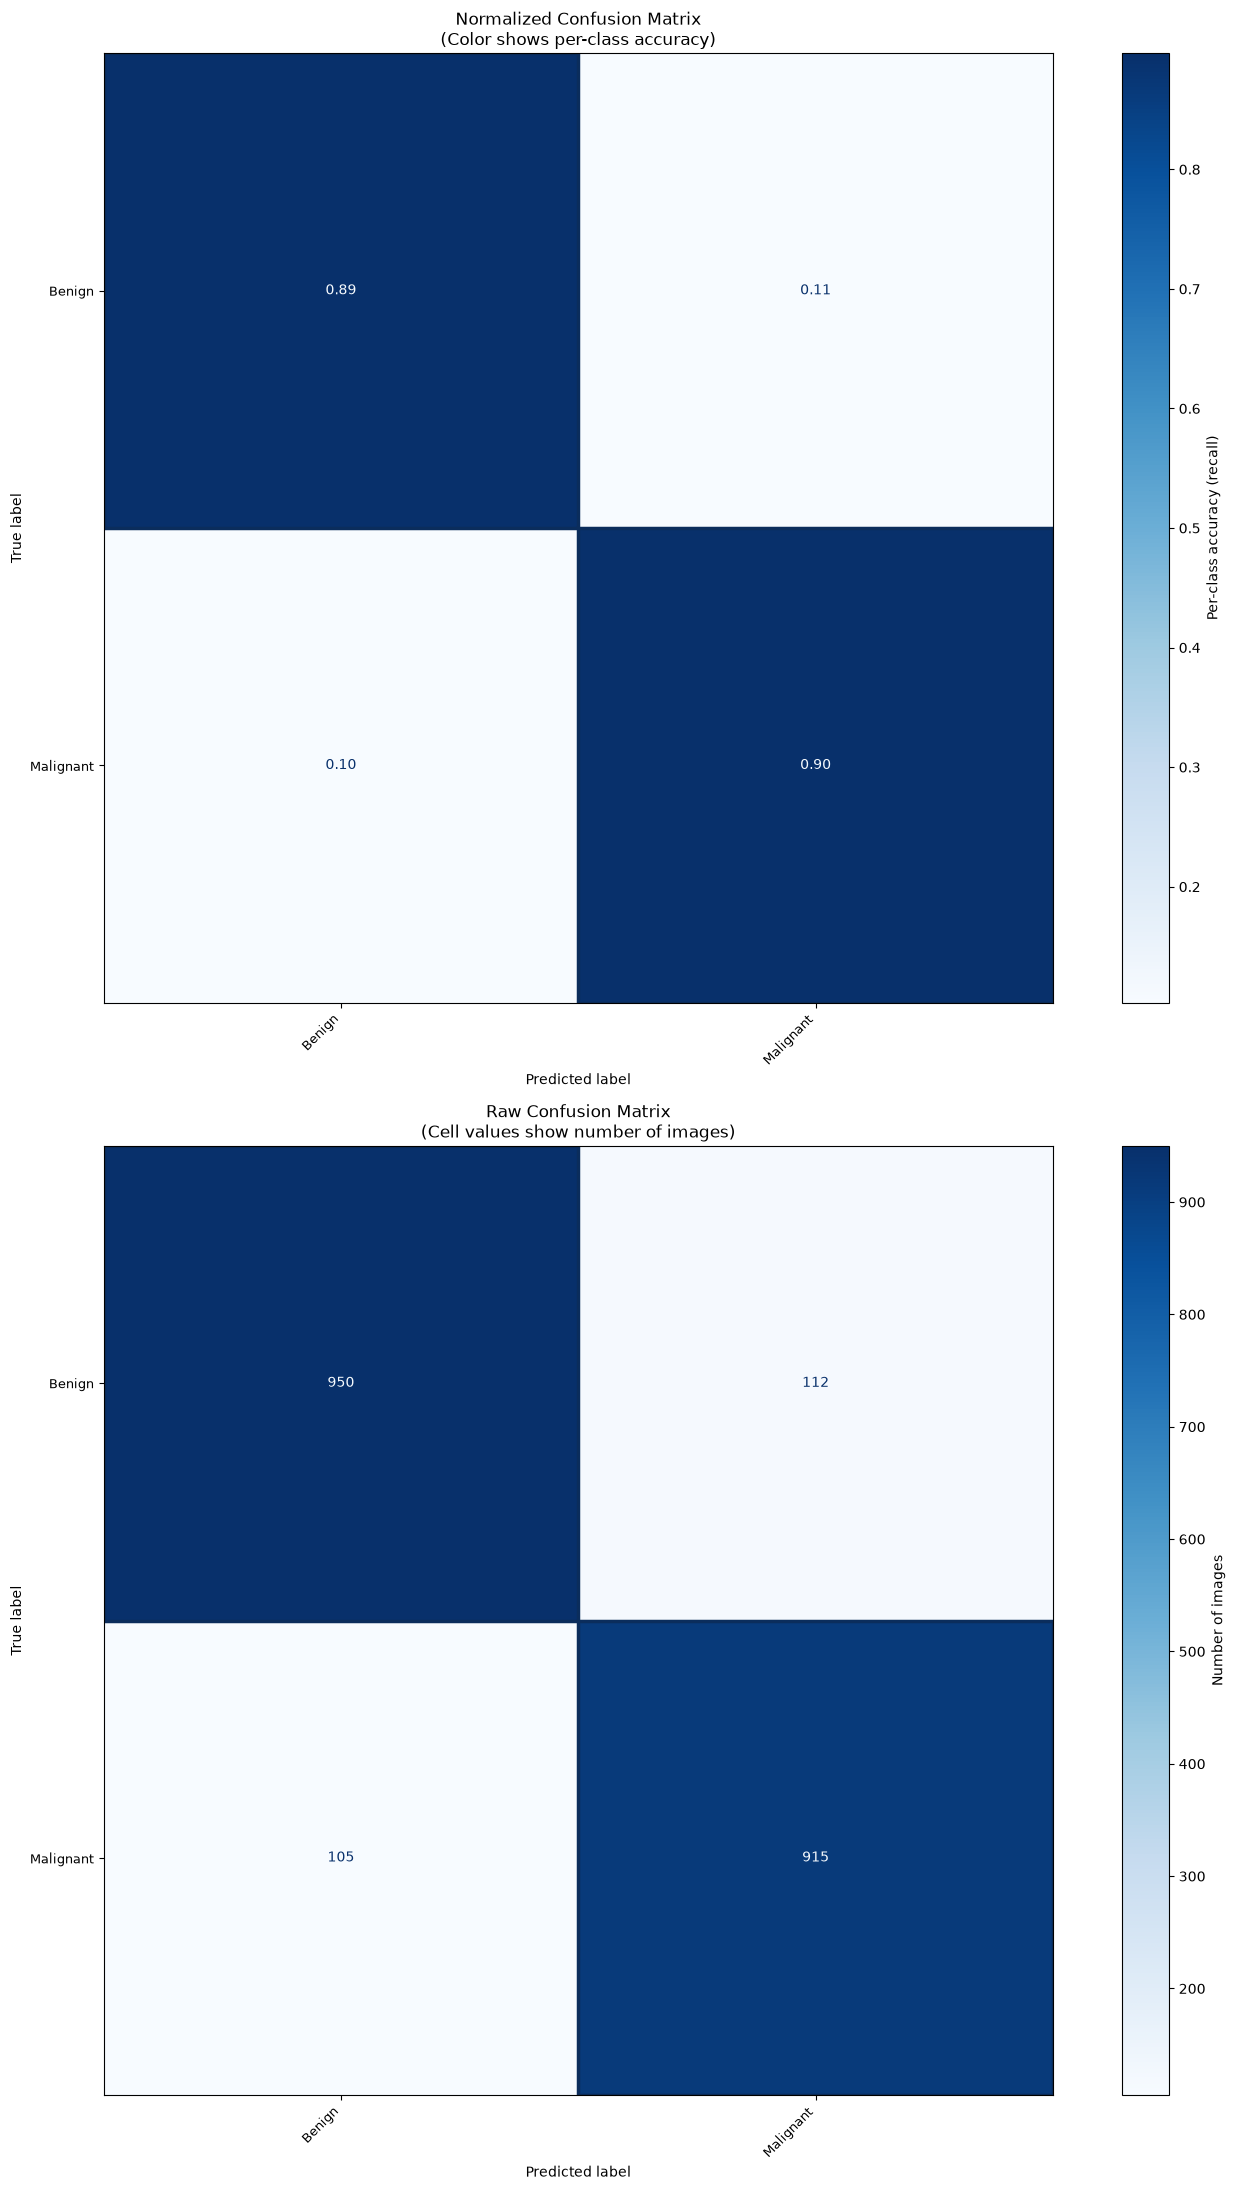

In [53]:
# Evaluate the model on the test set
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
convnext_model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels_batch in aug_test_loader:
        inputs = inputs.to(device)
        labels_batch = labels_batch.to(device)

        outputs = convnext_model(inputs)
        if hasattr(outputs, "logits"):
            outputs = outputs.logits

        loss = loss_function(outputs, labels_batch)
        predictions = outputs.argmax(dim=1)

        test_loss += loss.item() * labels_batch.size(0)
        test_correct += (predictions == labels_batch).sum().item()
        test_total += labels_batch.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

test_loss /= test_total
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)

cm = confusion_matrix(all_labels, all_predictions)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(2, 1, figsize=(14, 22))

normalized_display = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_encoder.classes_,
)
normalized_display.plot(
    ax=axes[0],
    values_format=".2f",
    xticks_rotation=45,
    cmap="Blues",
    colorbar=True,
)
normalized_display.im_.colorbar.set_label("Per-class accuracy (recall)")
axes[0].set_title("Normalized Confusion Matrix\n(Color shows per-class accuracy)")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

raw_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)
raw_display.plot(
    ax=axes[1],
    values_format="d",
    xticks_rotation=45,
    cmap="Blues",
    colorbar=True,
)
raw_display.im_.colorbar.set_label("Number of images")
axes[1].set_title("Raw Confusion Matrix\n(Cell values show number of images)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

for ax in axes:
    for diagonal_index in range(len(label_encoder.classes_)):
        ax.add_patch(
            plt.Rectangle(
                (diagonal_index - 0.5, diagonal_index - 0.5),
                1,
                1,
                fill=False,
                edgecolor="#0B2D5C",
                linewidth=2.5,
            )
        )
    plt.setp(ax.get_xticklabels(), ha="right", rotation=45, fontsize=9)
    plt.setp(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.show()

The final test accuracy is 0.8958.

As the model is not overfitting, it is possible that weakening the data augmentation could improve the model (reduce underfitting).

The end result is not too bad though.

However 105 of the malignant tumors being missed is quite bad, as that could be dangerous. Perhaps a more useful model would have a lower false negative rate (which would also probably mean a higher false positve rate, and a lower accuracy). One could do this by changing the loss function.

One future step is to use a deep learning approach to my heart attack prediction project which uses tabular data and see if I can get good results there.

Another future goal is to explore how to make the learning process faster.